In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")


def simulate_price(
    ticker,
    start          = "2016-01-01",
    days           = 252,
    iterations     = 100000,
    risk_free_rate = 0.20,
    seed           = None,
    plot           = True,
):
    """
    Monte Carlo stock price simulator using Geometric Brownian Motion.

    Parameters
    ----------
    ticker         : str   — required. Any yfinance ticker e.g. "AAPL", "ABUK.CA"
    start          : str   — optional. Historical data start date (default "2016-01-01")
    days           : int   — optional. Trading days to forecast (default 252 = 1 year)
    iterations     : int   — optional. Number of simulated paths (default 10,000)
    risk_free_rate : float — optional. Annualized risk-free rate (default 0.2 = EGX)
    seed           : int   — optional. Random seed for reproducibility (default None)
    plot           : bool  — optional. Show dashboard (default True)
    """

    # ─────────────────────────────────────────────
    # 1. Reproducibility
    # ─────────────────────────────────────────────
    if seed is not None:
        np.random.seed(seed)

    # ─────────────────────────────────────────────
    # 2. Download & validate data (silent)
    # ─────────────────────────────────────────────
    import contextlib, io, os, sys

    # Suppress all yfinance console output
    with contextlib.redirect_stdout(io.StringIO()), \
         contextlib.redirect_stderr(io.StringIO()):
        raw = yf.download(ticker, start=start, progress=False)["Close"]

    data = raw.squeeze()

    if data.empty:
        raise ValueError(f"No data returned for '{ticker}'. Check the ticker.")
    if data.isnull().sum() > len(data) * 0.1:
        raise ValueError(f"More than 10% missing values for '{ticker}'. Data quality too low.")
    if len(data) < 60:
        raise ValueError(f"Less than 60 days of history for '{ticker}'. Not enough to estimate parameters.")

    data = data.dropna()

    # ─────────────────────────────────────────────
    # 3. Estimate GBM parameters
    # ─────────────────────────────────────────────
    log_returns = np.log(data / data.shift(1)).dropna()

    u     = float(log_returns.mean())
    var   = float(log_returns.var())
    stdev = float(log_returns.std())
    drift = u - (0.5 * var)         # Itô correction
    S0    = float(data.iloc[-1])

    # ─────────────────────────────────────────────
    # 4. Simulate paths — Geometric Brownian Motion
    #    S(t) = S(t-1) * exp(drift + σ * Z), Z ~ N(0,1)
    # ─────────────────────────────────────────────
    Z             = norm.ppf(np.random.rand(days, iterations))
    daily_returns = np.exp(drift + stdev * Z)

    price_paths      = np.zeros((days, iterations))
    price_paths[0]   = S0
    for t in range(1, days):
        price_paths[t] = price_paths[t - 1] * daily_returns[t]

    # ─────────────────────────────────────────────
    # 5. Future date index (business days only)
    # ─────────────────────────────────────────────
    last_date    = data.index[-1]
    future_dates = pd.bdate_range(
        start   = last_date + pd.offsets.BDay(1),
        periods = days,
    )

    # ─────────────────────────────────────────────
    # 6. Extract statistics
    # ─────────────────────────────────────────────
    final_prices    = price_paths[-1, :]

    expected_price  = float(np.mean(final_prices))
    median_price    = float(np.median(final_prices))
    pct_5           = float(np.percentile(final_prices, 5))
    pct_25          = float(np.percentile(final_prices, 25))
    pct_75          = float(np.percentile(final_prices, 75))
    pct_95          = float(np.percentile(final_prices, 95))

    upside_expected = (expected_price - S0) / S0
    upside_median   = (median_price   - S0) / S0
    prob_gain       = float(np.mean(final_prices > S0))
    var_95          = S0 - pct_5
    var_95_pct      = var_95 / S0

    median_path       = np.median(price_paths, axis=1)
    median_log_rets   = np.diff(np.log(median_path))
    sharpe_annualized = (
        (median_log_rets.mean() - risk_free_rate / 252)
        / median_log_rets.std()
        * np.sqrt(252)
    )

    band_5  = np.percentile(price_paths, 5,  axis=1)
    band_25 = np.percentile(price_paths, 25, axis=1)
    band_75 = np.percentile(price_paths, 75, axis=1)
    band_95 = np.percentile(price_paths, 95, axis=1)

    # ─────────────────────────────────────────────
    # 7. HTML summary table
    # ─────────────────────────────────────────────
    TEAL   = "#0F6E56"
    TEAL_L = "#E1F5EE"
    GRAY   = "#444441"

    def badge(text, positive):
        bg  = "#EAF3DE" if positive else "#FCEBEB"
        clr = "#3B6D11" if positive else "#A32D2D"
        return (f'<span style="background:{bg};color:{clr};font-weight:500;'
                f'padding:2px 8px;border-radius:99px;font-size:12px;">{text}</span>')

    rows = [
        ("Current Price (S₀)",
         f"{S0:,.2f}",
         ""),
        ("Expected Price (mean)",
         f"{expected_price:,.2f}",
         badge(f"{'+'if upside_expected>0 else ''}{upside_expected:.2%} vs today",
               upside_expected > 0)),
        ("Median Price",
         f"{median_price:,.2f}",
         badge(f"{'+'if upside_median>0 else ''}{upside_median:.2%} vs today",
               upside_median > 0)),
        ("Bull Case — 95th Percentile",
         f"{pct_95:,.2f}",
         badge(f"+{(pct_95-S0)/S0:.2%} vs today", True)),
        ("Bear Case — 5th Percentile",
         f"{pct_5:,.2f}",
         badge(f"{(pct_5-S0)/S0:.2%} vs today", False)),
        ("95% Value at Risk (VaR)",
         f"{var_95:,.2f}  ({var_95_pct:.2%})",
         badge("max expected loss in 95% of scenarios", False)),
        ("Probability of Gain",
         f"{prob_gain:.2%}",
         badge("P(end price > today)", prob_gain > 0.5)),
        ("Annualized Sharpe (median path)",
         f"{sharpe_annualized:.3f}",
         badge("risk-adjusted return", sharpe_annualized > 0)),
    ]

    html = f"""
    <div style="overflow-x:auto; margin:16px 0; font-family:Arial,sans-serif;">
    <table style="border-collapse:collapse; font-size:12px; width:100%;">
    <caption style="font-size:14px; font-weight:500; text-align:left;
                    padding:8px 0; color:{GRAY};">
        MONTE CARLO FORECAST SUMMARY — {ticker.upper()}
        &nbsp;<span style="font-size:11px;color:#888;">
            {iterations:,} simulations &nbsp;·&nbsp;
            {days} trading days &nbsp;·&nbsp;
            history: {data.index[0].date()} → {data.index[-1].date()}
        </span>
    </caption>
    <thead><tr>
      <th style="background:{TEAL};color:#fff;padding:8px 14px;
                 text-align:left;font-size:12px;">Metric</th>
      <th style="background:{TEAL};color:#fff;padding:8px 14px;
                 text-align:right;font-size:12px;">Value</th>
      <th style="background:{TEAL};color:#fff;padding:8px 14px;
                 text-align:center;font-size:12px;">Context</th>
    </tr></thead><tbody>"""

    for i, (label, value, context) in enumerate(rows):
        bg = TEAL_L if i % 2 == 0 else "#ffffff"
        html += (
            f'<tr style="background:{bg};">'
            f'<td style="padding:8px 14px;border:0.5px solid #D3D1C7;">{label}</td>'
            f'<td style="padding:8px 14px;border:0.5px solid #D3D1C7;'
            f'    text-align:right;font-weight:500;">{value}</td>'
            f'<td style="padding:8px 14px;border:0.5px solid #D3D1C7;'
            f'    text-align:center;">{context}</td>'
            f'</tr>'
        )
    html += "</tbody></table></div>"
    display(HTML(html))

    # ─────────────────────────────────────────────
    # 8. Dashboard — 3-panel plot
    # ─────────────────────────────────────────────
    if plot:
        TEAL_D = "#0F6E56"
        TEAL_M = "#1D9E75"
        RED    = "#E24B4A"
        AMBER  = "#BA7517"

        fig = plt.figure(figsize=(16, 12))
        fig.patch.set_facecolor("#FAFAFA")
        gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

        ax1 = fig.add_subplot(gs[0, :])   # full-width top
        ax2 = fig.add_subplot(gs[1, 0])   # bottom left
        ax3 = fig.add_subplot(gs[1, 1])   # bottom right

        # ── Panel 1: Percentile bands ─────────────────────────
        ax1.fill_between(future_dates, band_5,  band_95,
                         alpha=0.15, color=TEAL_M, label="5th – 95th percentile")
        ax1.fill_between(future_dates, band_25, band_75,
                         alpha=0.30, color=TEAL_M, label="25th – 75th percentile")
        ax1.plot(future_dates, median_path,
                 color=TEAL_D, linewidth=2, label="Median path", zorder=5)
        ax1.axhline(S0, color=AMBER, linewidth=1.2,
                    linestyle="--", label=f"Current price  {S0:,.2f}", zorder=4)

        ax1.set_title(f"Monte Carlo Price Simulation — {ticker.upper()}",
                      fontsize=12, fontweight="bold", color=GRAY, pad=10)
        ax1.set_xlabel("Date", fontsize=10)
        ax1.set_ylabel("Price", fontsize=10)
        ax1.legend(fontsize=9, loc="upper left", framealpha=0.9)
        ax1.xaxis.set_major_formatter(
            plt.matplotlib.dates.DateFormatter("%b '%y"))
        ax1.xaxis.set_major_locator(
            plt.matplotlib.dates.MonthLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
        ax1.spines[["top", "right"]].set_visible(False)
        ax1.set_facecolor("#FAFAFA")
        ax1.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:,.1f}"))

        # ── Panel 2: Final price histogram ────────────────────
        ax2.hist(final_prices, bins=80, color=TEAL_M,
                 edgecolor="white", linewidth=0.3, alpha=0.85)
        ax2.axvline(S0,           color=AMBER,    linewidth=1.5,
                    linestyle="--", label=f"Current  {S0:,.2f}")
        ax2.axvline(median_price, color=TEAL_D,   linewidth=1.5,
                    linestyle="-",  label=f"Median  {median_price:,.2f}")
        ax2.axvline(pct_5,        color=RED,       linewidth=1.2,
                    linestyle=":",  label=f"5th pct  {pct_5:,.2f}")
        ax2.axvline(pct_95,       color="#639922", linewidth=1.2,
                    linestyle=":",  label=f"95th pct  {pct_95:,.2f}")

        ax2.set_title("Distribution of Final Prices (Period End)",
                      fontsize=11, fontweight="bold", color=GRAY, pad=10)
        ax2.set_xlabel("Simulated Price", fontsize=10)
        ax2.set_ylabel("Frequency",       fontsize=10)
        ax2.legend(fontsize=8, framealpha=0.9)
        ax2.spines[["top", "right"]].set_visible(False)
        ax2.set_facecolor("#FAFAFA")
        ax2.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax2.text(0.97, 0.95,
                 f"P(gain) = {prob_gain:.1%}",
                 transform=ax2.transAxes,
                 ha="right", va="top", fontsize=10, fontweight="bold",
                 color=TEAL_D if prob_gain > 0.5 else RED)

        # ── Panel 3: Historical + forecast ───────────────────
        hist_plot = data.iloc[-252:]
        ax3.plot(hist_plot.index, hist_plot.values,
                 color=GRAY, linewidth=1.5, label="Historical (1Y)")
        ax3.plot(future_dates, median_path,
                 color=TEAL_D, linewidth=2,
                 linestyle="--", label="Forecast median")
        ax3.fill_between(future_dates, band_5, band_95,
                         alpha=0.12, color=TEAL_M)
        ax3.axvline(last_date, color=AMBER,
                    linewidth=1, linestyle=":", alpha=0.8)
        ax3.annotate("Forecast start",
                     xy=(last_date, float(hist_plot.iloc[-1])),
                     xytext=(15, -20), textcoords="offset points",
                     fontsize=8, color=AMBER,
                     arrowprops=dict(arrowstyle="->", color=AMBER, lw=0.8))

        ax3.set_title("Historical + Forecast",
                      fontsize=11, fontweight="bold", color=GRAY, pad=10)
        ax3.set_xlabel("Date", fontsize=10)
        ax3.set_ylabel("Price", fontsize=10)
        ax3.legend(fontsize=9, framealpha=0.9)
        ax3.xaxis.set_major_formatter(
            plt.matplotlib.dates.DateFormatter("%b '%y"))
        ax3.xaxis.set_major_locator(
            plt.matplotlib.dates.MonthLocator(interval=3))
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha="right")
        ax3.spines[["top", "right"]].set_visible(False)
        ax3.set_facecolor("#FAFAFA")
        ax3.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:,.1f}"))

        fig.suptitle(
            f"PricePath  ·  {ticker.upper()}  ·  "
            f"{iterations:,} simulations  ·  {days} trading days",
            fontsize=13, fontweight="bold", color=TEAL_D, y=1.01,
        )
        plt.tight_layout()
        plt.show()

    return None


# ─────────────────────────────────────────────
# Example calls
# ─────────────────────────────────────────────
# simulate_price("ABUK.CA")
# simulate_price("KO")
# simulate_price("AAPL", risk_free_rate=0.045)
# simulate_price("ABUK.CA", days=126)              # 6-month forecast
# simulate_price("COMI.CA", iterations=5000, seed=42)     # reproducible
# simulate_price("ABUK.CA", start="2020-01-01")           # shorter history

Metric,Value,Context
Current Price (S₀),312.90,
Expected Price (mean),401.29,+28.25% vs today
Median Price,385.48,+23.20% vs today
Bull Case — 95th Percentile,617.93,+97.48% vs today
Bear Case — 5th Percentile,238.84,-23.67% vs today
95% Value at Risk (VaR),74.06 (23.67%),max expected loss in 95% of scenarios
Probability of Gain,76.46%,P(end price > today)
Annualized Sharpe (median path),2.403,risk-adjusted return


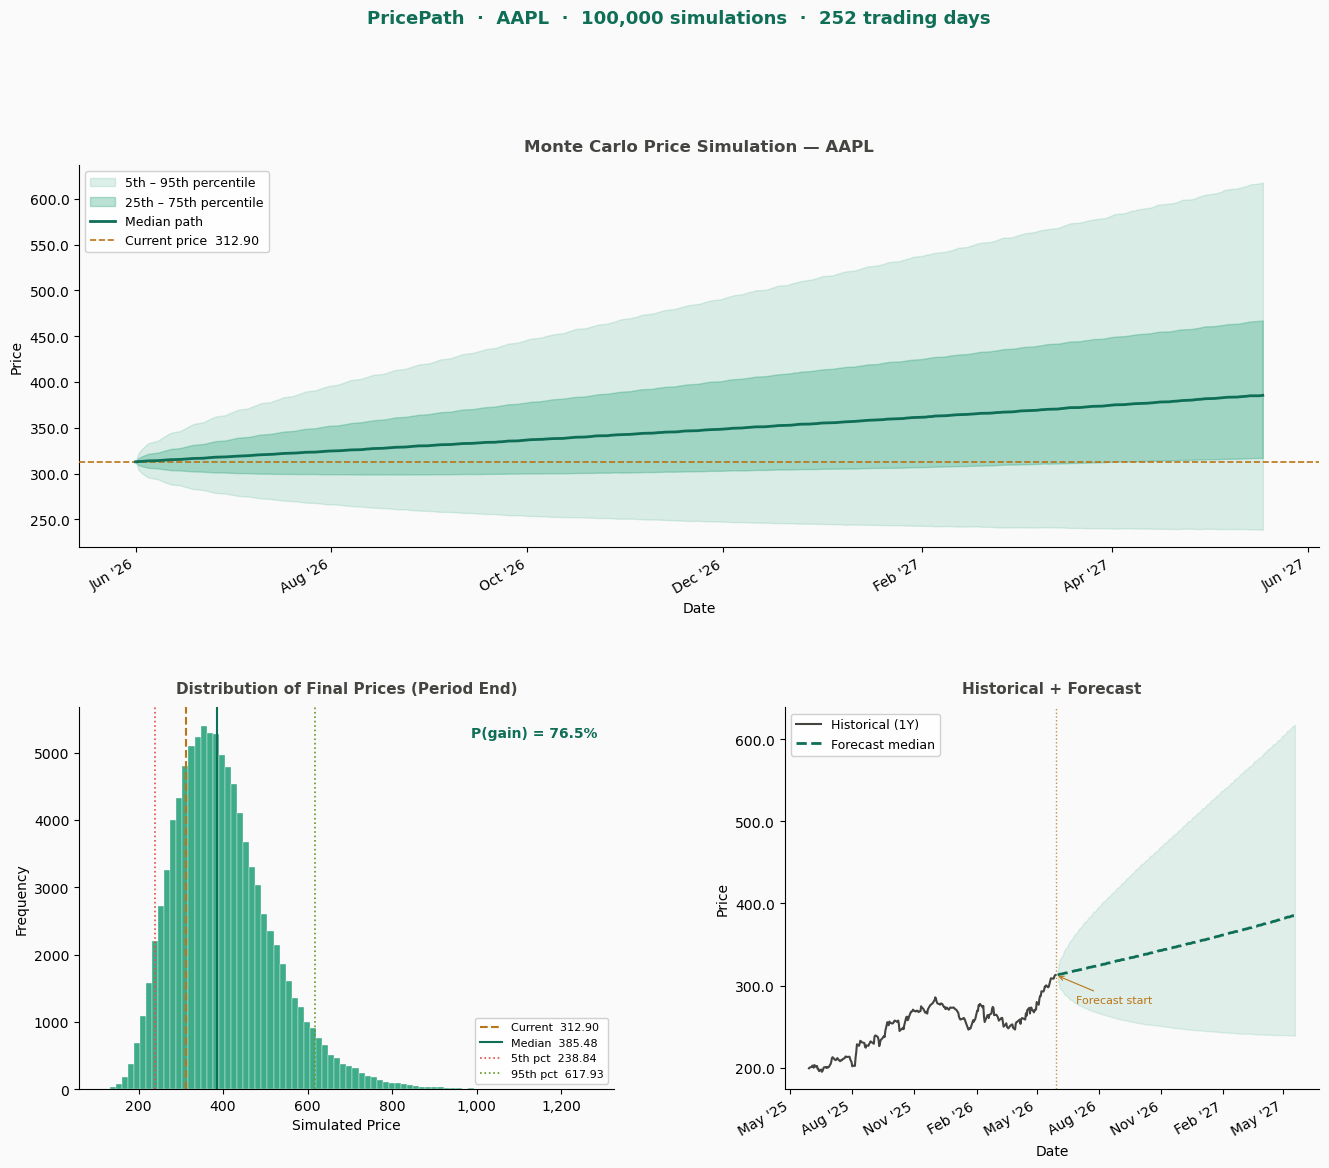

In [4]:
simulate_price("AAPL")